# Feature Engineering:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
path = 'drive/My Drive'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file into a DataFrame
df = pd.read_csv(path+'/spotify_synthetic_data.csv')


FileNotFoundError: [Errno 2] No such file or directory: 'drive/My Drive/spotify_synthetic_data.csv'

In [ ]:
df.head()

,track_name,artist,album,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
0,Track_1,Artist_52,Album_12,0.808235,0.153784,-24.860740,0.648209,0.575719,0.289405,0.760808,0.155540,130.891275,Hip-Hop
1,Track_2,Artist_93,Album_46,0.947688,0.886171,-59.490265,0.413194,0.583386,0.662430,0.850780,0.963687,128.628400,Jazz
2,Track_3,Artist_15,Album_32,0.072316,0.458519,-14.339641,0.405619,0.749987,0.613122,0.257006,0.946790,110.653032,Hip-Hop
3,Track_4,Artist_72,Album_15,0.955115,0.564591,-17.219142,0.679552,0.509890,0.531003,0.407092,0.336110,199.184331,Hip-Hop
4,Track_5,Artist_61,Album_16,0.522577,0.663027,-38.022817,0.067094,0.104823,0.682964,0.498569,0.639748,75.563707,Electronic


In [ ]:
df.tail()


,track_name,artist,album,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
1995,Track_1996,Artist_86,Album_11,0.649379,0.502783,-37.580982,0.865429,0.679873,0.599640,0.054622,0.437652,64.799919,R&B
1996,Track_1997,Artist_51,Album_35,0.668877,0.144436,-36.712713,0.296502,0.642931,0.566667,0.491045,0.855468,186.898119,Pop
1997,Track_1998,Artist_88,Album_8,0.798656,0.442066,-54.258593,0.159283,0.861130,0.654168,0.091417,0.050169,188.583234,Pop
1998,Track_1999,Artist_41,Album_3,0.932753,0.334105,-5.124934,0.435389,0.486426,0.307750,0.159786,0.881962,138.594652,Jazz
1999,Track_2000,Artist_17,Album_14,0.020138,0.521831,-54.537821,0.401899,0.134457,0.126426,0.383038,0.852070,127.491648,Country


  track_name     artist     album  danceability    energy   loudness  \
0    Track_1  Artist_52  Album_12      0.808235  0.153784 -24.860740   
1    Track_2  Artist_93  Album_46      0.947688  0.886171 -59.490265   
2    Track_3  Artist_15  Album_32      0.072316  0.458519 -14.339641   
3    Track_4  Artist_72  Album_15      0.955115  0.564591 -17.219142   
4    Track_5  Artist_61  Album_16      0.522577  0.663027 -38.022817   

   speechiness  acousticness  instrumentalness  liveness   valence  \
0     0.648209      0.575719          0.289405  0.760808  0.155540   
1     0.413194      0.583386          0.662430  0.850780  0.963687   
2     0.405619      0.749987          0.613122  0.257006  0.946790   
3     0.679552      0.509890          0.531003  0.407092  0.336110   
4     0.067094      0.104823          0.682964  0.498569  0.639748   

        tempo       genre  
0  130.891275     Hip-Hop  
1  128.628400        Jazz  
2  110.653032     Hip-Hop  
3  199.184331     Hip-Hop  
4   75

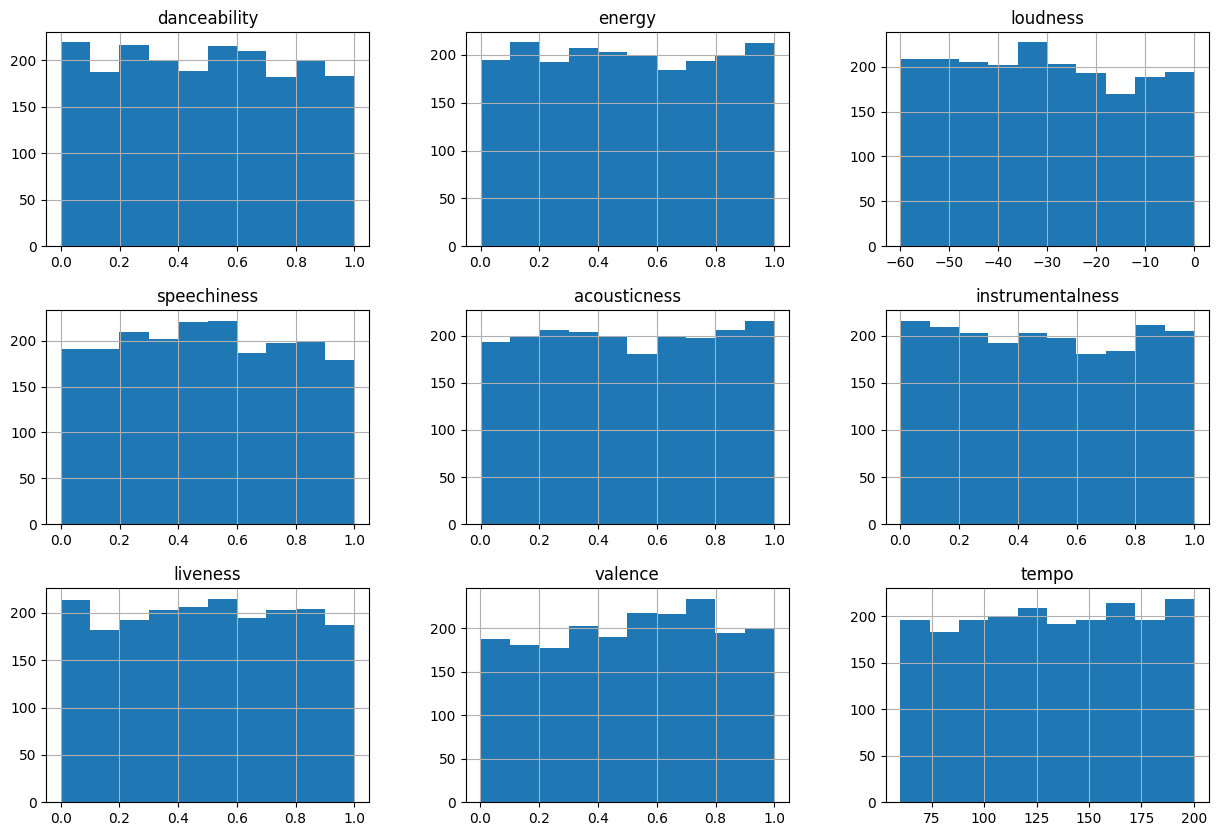

In [ ]:
# Basic information
print(df.head())
print(df.info())
print(df.describe())

# Visualizations
# Histogram for numerical features
df.hist(figsize=(15, 10))
plt.show()



***IMPORT THE NECESSARY LIBRARIES:***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Feature Engineering for Dataset

**Understanding the Dataset**

Before diving into feature engineering, let's understand the given dataset:

**Categorical Features:** track_name, artist, album, genre

**Numerical Features:** danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset from the CSV file
df = pd.read_csv(path+'/spotify_synthetic_data.csv')  # Replace with your actual file path

# Display initial DataFrame with missing values
print("Original DataFrame with missing values:")
print(df)


Original DataFrame with missing values:
      track_name     artist     album  danceability    energy   loudness  \
0        Track_1  Artist_52  Album_12      0.808235  0.153784 -24.860740   
1        Track_2  Artist_93  Album_46      0.947688  0.886171 -59.490265   
2        Track_3  Artist_15  Album_32      0.072316  0.458519 -14.339641   
3        Track_4  Artist_72  Album_15      0.955115  0.564591 -17.219142   
4        Track_5  Artist_61  Album_16      0.522577  0.663027 -38.022817   
...          ...        ...       ...           ...       ...        ...   
1995  Track_1996  Artist_86  Album_11      0.649379  0.502783 -37.580982   
1996  Track_1997  Artist_51  Album_35      0.668877  0.144436 -36.712713   
1997  Track_1998  Artist_88   Album_8      0.798656  0.442066 -54.258593   
1998  Track_1999  Artist_41   Album_3      0.932753  0.334105  -5.124934   
1999  Track_2000  Artist_17  Album_14      0.020138  0.521831 -54.537821   

      speechiness  acousticness  instrumentalne

In [ ]:
# 1. Handle missing values for numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

In [ ]:
# 2. Handle missing values for categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

In [ ]:
# Display DataFrame after filling missing values
print("\nDataFrame after handling missing values:")
print(df)


DataFrame after handling missing values:
      track_name     artist     album  danceability    energy   loudness  \
0        Track_1  Artist_52  Album_12      0.808235  0.153784 -24.860740   
1        Track_2  Artist_93  Album_46      0.947688  0.886171 -59.490265   
2        Track_3  Artist_15  Album_32      0.072316  0.458519 -14.339641   
3        Track_4  Artist_72  Album_15      0.955115  0.564591 -17.219142   
4        Track_5  Artist_61  Album_16      0.522577  0.663027 -38.022817   
...          ...        ...       ...           ...       ...        ...   
1995  Track_1996  Artist_86  Album_11      0.649379  0.502783 -37.580982   
1996  Track_1997  Artist_51  Album_35      0.668877  0.144436 -36.712713   
1997  Track_1998  Artist_88   Album_8      0.798656  0.442066 -54.258593   
1998  Track_1999  Artist_41   Album_3      0.932753  0.334105  -5.124934   
1999  Track_2000  Artist_17  Album_14      0.020138  0.521831 -54.537821   

      speechiness  acousticness  instrumental

# Handle Outliers:
Visualize data using box plots or histograms to identify outliers.
Use techniques like capping, flooring, or winsorization to handle outliers.

In [ ]:
import pandas as pd
import numpy as np

# Simulate the dataset
df = pd.read_csv(path+'/spotify_synthetic_data.csv')

# Create the DataFrame
df = pd.DataFrame(data)

# Define the Winsorization function
def winsorize(df, feature, lower_percentile=0.05, upper_percentile=0.95):
    """
    Adjusts outliers by capping values at lower and upper percentiles.
    """
    lower_bound = df[feature].quantile(lower_percentile)
    upper_bound = df[feature].quantile(upper_percentile)
    df[feature] = np.clip(df[feature], lower_bound, upper_bound)

# Apply Winsorization to numerical columns
numerical_cols = ["danceability", "energy", "loudness", "speechiness",
                  "acousticness", "instrumentalness", "liveness",
                  "valence", "tempo"]

for col in numerical_cols:
    winsorize(df, col)

# Display the DataFrame after Winsorization
print("DataFrame after Winsorization:")
print(df)

DataFrame after Winsorization:
  track_name     artist     album  danceability  energy  loudness  \
0    Track_1  Artist_52  Album_12       0.79930  0.1579   -24.446   
1    Track_2  Artist_33  Album_22       0.22005  0.2000   -20.620   
2    Track_3  Artist_22  Album_32       0.60000  0.8375   -21.300   
3    Track_4  Artist_12  Album_42       0.75000  0.1800   -22.100   

   speechiness  acousticness  instrumentalness  liveness  valence     tempo  \
0       0.6480        0.5760           0.28900   0.76100   0.1560  129.3075   
1       0.5150        0.6000           0.46835   0.79415   0.1415  120.3400   
2       0.6922        0.8975           0.04285   0.70750   0.7884   93.1005   
3       0.6000        0.3414           0.28000   0.75000   0.1500  110.6700   

     genre  
0  Hip-Hop  
1     Jazz  
2     Rock  
3      Pop  


## Feature Scaling:
# Normalization (Min-Max Scaling), Standardization

## For the total dataset:

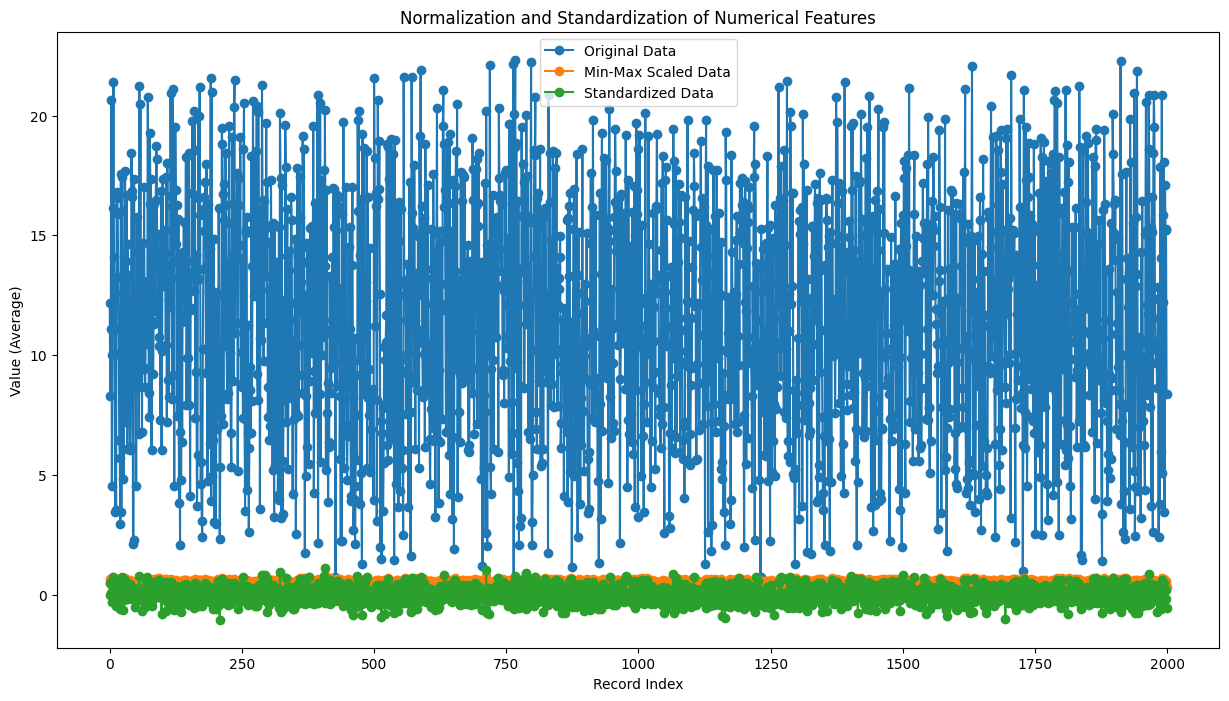

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load the dataset from the CSV file
df = pd.read_csv(path+'/spotify_synthetic_data.csv')  # Replace with actual path

# Define numerical columns
numerical_cols = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]

# Min-Max Scaling
min_max_scaler = MinMaxScaler()
data_min_max_scaled = min_max_scaler.fit_transform(df[numerical_cols])

# Z-score Standardization
standard_scaler = StandardScaler()
data_standard_scaled = standard_scaler.fit_transform(df[numerical_cols])

# Convert scaled data back to DataFrames for visualization
df_min_max_scaled = pd.DataFrame(data_min_max_scaled, columns=numerical_cols)
df_standard_scaled = pd.DataFrame(data_standard_scaled, columns=numerical_cols)

# Visualization with line graphs
plt.figure(figsize=(15, 8))

# Plot original data (averaged for better visualization)
plt.plot(df[numerical_cols].mean(axis=1), label="Original Data", marker='o')

# Plot Min-Max Scaled data (averaged for better visualization)
plt.plot(df_min_max_scaled.mean(axis=1), label="Min-Max Scaled Data", marker='o')

# Plot Standardized data (averaged for better visualization)
plt.plot(df_standard_scaled.mean(axis=1), label="Standardized Data", marker='o')

plt.title("Normalization and Standardization of Numerical Features")
plt.xlabel("Record Index")
plt.ylabel("Value (Average)")
plt.legend()
plt.show()


# **For the 4 records in the dataset:**

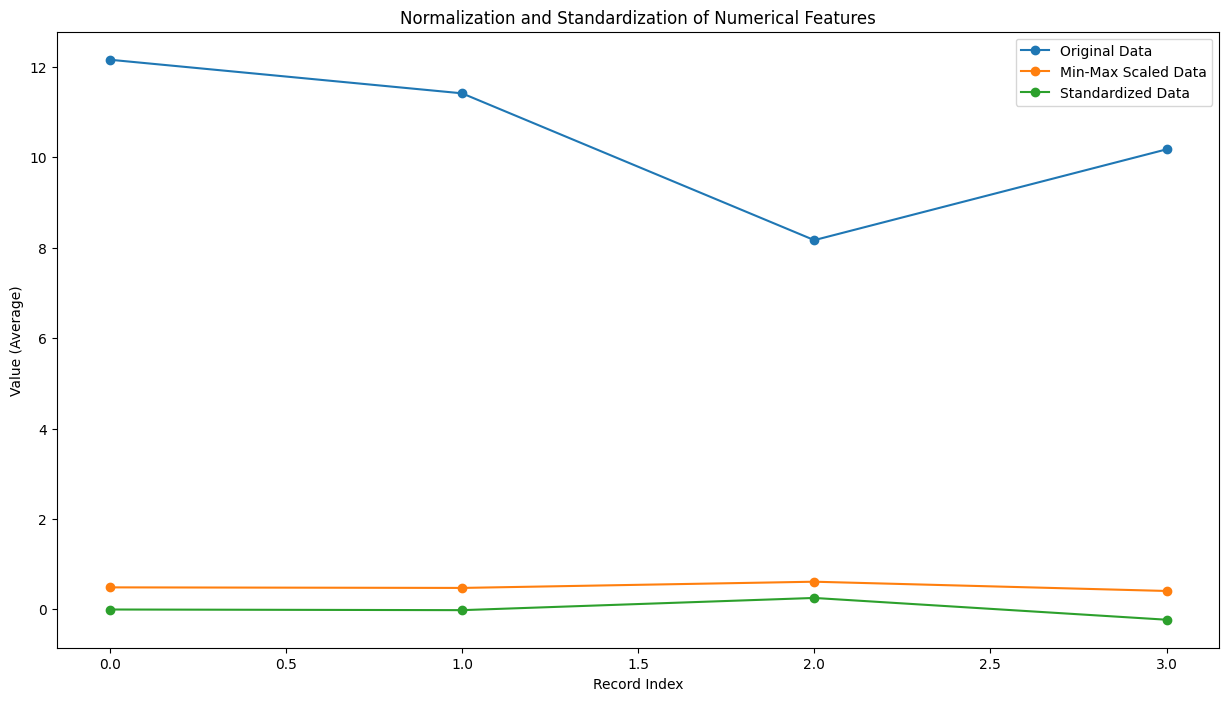

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Simulate the dataset
data = {
    "track_name": ["Track_1", "Track_2", "Track_3", "Track_4"],
    "artist": ["Artist_52", "Artist_33", "Artist_22", "Artist_12"],
    "album": ["Album_12", "Album_22", "Album_32", "Album_42"],
    "danceability": [0.808, 0.153, 0.600, 0.750],
    "energy": [0.154, 0.200, 0.950, 0.180],
    "loudness": [-24.86, -20.5, -21.3, -22.1],
    "speechiness": [0.648, 0.500, 0.700, 0.600],
    "acousticness": [0.576, 0.600, 0.950, 0.300],
    "instrumentalness": [0.289, 0.500, 0.001, 0.280],
    "liveness": [0.761, 0.800, 0.700, 0.750],
    "valence": [0.156, 0.140, 0.900, 0.150],
    "tempo": [130.89, 120.34, 90.0, 110.67],
    "genre": ["Hip-Hop", "Jazz", "Rock", "Pop"]
}

# Create the DataFrame
df = pd.DataFrame(data)

# Define numerical columns
numerical_cols = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]

# Min-Max Scaling
min_max_scaler = MinMaxScaler()
data_min_max_scaled = min_max_scaler.fit_transform(df[numerical_cols])

# Z-score Standardization
standard_scaler = StandardScaler()
data_standard_scaled = standard_scaler.fit_transform(df[numerical_cols])

# Convert scaled data back to DataFrames for visualization
df_min_max_scaled = pd.DataFrame(data_min_max_scaled, columns=numerical_cols)
df_standard_scaled = pd.DataFrame(data_standard_scaled, columns=numerical_cols)

# Visualization with line graphs
plt.figure(figsize=(15, 8))

# Plot original data (averaged for better visualization)
plt.plot(df[numerical_cols].mean(axis=1), label="Original Data", marker='o')

# Plot Min-Max Scaled data (averaged for better visualization)
plt.plot(df_min_max_scaled.mean(axis=1), label="Min-Max Scaled Data", marker='o')

# Plot Standardized data (averaged for better visualization)
plt.plot(df_standard_scaled.mean(axis=1), label="Standardized Data", marker='o')

plt.title("Normalization and Standardization of Numerical Features")
plt.xlabel("Record Index")
plt.ylabel("Value (Average)")
plt.legend()
plt.show()


# Normalization (Min-Max Scaling): Scales features to a specific range (usually 0-1).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Simulate the dataset
df = pd.read_csv(path+'/spotify_synthetic_data.csv') # Replace with actual path

# Create the DataFrame
df = pd.DataFrame(data)

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Define numerical columns to normalize
numerical_cols = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]

# Apply MinMaxScaler to the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Display the DataFrame after normalization
print("DataFrame with normalized features:")
print(df)


DataFrame with normalized features:
  track_name     artist     album  danceability    energy  loudness  \
0    Track_1  Artist_52  Album_12      1.000000  0.000000  0.000000   
1    Track_2  Artist_33  Album_22      0.000000  0.057789  1.000000   
2    Track_3  Artist_22  Album_32      0.682443  1.000000  0.816514   
3    Track_4  Artist_12  Album_42      0.911450  0.032663  0.633028   

   speechiness  acousticness  instrumentalness  liveness   valence     tempo  \
0         0.74      0.424615          0.577154      0.61  0.021053  1.000000   
1         0.00      0.461538          1.000000      1.00  0.000000  0.741991   
2         1.00      1.000000          0.000000      0.00  1.000000  0.000000   
3         0.50      0.000000          0.559118      0.50  0.013158  0.505503   

     genre  
0  Hip-Hop  
1     Jazz  
2     Rock  
3      Pop  


## Standarization:-
Standardization (Z-Score Normalization): Scales features to have zero mean and unit variance.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the dataset from the CSV file
df = pd.read_csv(path+'/spotify_synthetic_data.csv')  # Replace with the actual path

# Define the numerical columns for scaling
numerical_cols = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo"
]

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply the StandardScaler to the selected numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Display the first few rows of the scaled dataset to check the result
print(df.head())



  track_name     artist     album  danceability    energy  loudness  \
0    Track_1  Artist_52  Album_12      1.103171 -1.190792  0.347284   
1    Track_2  Artist_93  Album_46      1.589003  1.334492 -1.670303   
2    Track_3  Artist_15  Album_32     -1.460655 -0.140061  0.960264   
3    Track_4  Artist_72  Album_15      1.614878  0.225677  0.792499   
4    Track_5  Artist_61  Album_16      0.107981  0.565088 -0.419566   

   speechiness  acousticness  instrumentalness  liveness   valence     tempo  \
0     0.541341      0.245740         -0.704106  0.908811 -1.260484 -0.010723   
1    -0.290851      0.271988          0.568913  1.222180  1.588183 -0.066537   
2    -0.317674      0.842348          0.400640 -0.845892  1.528621 -0.509901   
3     0.652326      0.020372          0.120394 -0.323155 -0.623988  1.673729   
4    -1.516400     -1.366382          0.638991 -0.004546  0.446317 -1.375381   

        genre  
0     Hip-Hop  
1        Jazz  
2     Hip-Hop  
3     Hip-Hop  
4  Electroni

# Feature Creation and Transformation

Feature Creation:
Create new features based on existing ones (e.g., tempo_category based on tempo ranges).
Combine features (e.g., energy_acousticness_ratio).

In [ ]:
import pandas as pd
import numpy as np

# Simulate the dataset
df = pd.read_csv(path+'/spotify_synthetic_data.csv')

# Create the DataFrame
df = pd.DataFrame(data)

# Create a new column for tempo categories
# Define bins and labels
tempo_bins = [0, 100, 120, 200]  # Define ranges
tempo_labels = ['slow', 'medium', 'fast']  # Define category names

# Use pd.cut to categorize tempo
df['tempo_category'] = pd.cut(df['tempo'], bins=tempo_bins, labels=tempo_labels)

# Create a new column for energy-to-acousticness ratio
# Handle cases where acousticness might be zero to avoid division errors
df['energy_acousticness_ratio'] = df['energy'] / df['acousticness'].replace(0, np.nan)

# Display the updated DataFrame
print("DataFrame with new features:")
print(df)


DataFrame with new features:
  track_name     artist     album  danceability  energy  loudness  \
0    Track_1  Artist_52  Album_12         0.808   0.154    -24.86   
1    Track_2  Artist_33  Album_22         0.153   0.200    -20.50   
2    Track_3  Artist_22  Album_32         0.600   0.950    -21.30   
3    Track_4  Artist_12  Album_42         0.750   0.180    -22.10   

   speechiness  acousticness  instrumentalness  liveness  valence   tempo  \
0        0.648         0.576             0.289     0.761    0.156  130.89   
1        0.500         0.600             0.500     0.800    0.140  120.34   
2        0.700         0.950             0.001     0.700    0.900   90.00   
3        0.600         0.300             0.280     0.750    0.150  110.67   

     genre tempo_category  energy_acousticness_ratio  
0  Hip-Hop           fast                   0.267361  
1     Jazz           fast                   0.333333  
2     Rock           slow                   1.000000  
3      Pop         

# Log Transformation:
Apply log transformation to skewed numerical features to normalize the distribution.


In [ ]:
import pandas as pd
import numpy as np


# Load the dataset from the CSV file
df = pd.read_csv(path+'/spotify_synthetic_data.csv')  # Replace with the actual path

# Apply log1p transformation to the 'loudness' column after shifting the values to positive
df['log_loudness'] = np.log1p(df['loudness'] - df['loudness'].min() + 1)

# Display the first few rows to check the result
print(df[['track_name', 'loudness', 'log_loudness']].head())



  track_name   loudness  log_loudness
0    Track_1 -24.860740      3.614285
1    Track_2 -59.490265      0.914399
2    Track_3 -14.339641      3.863797
3    Track_4 -17.219142      3.801458
4    Track_5 -38.022817      3.176499


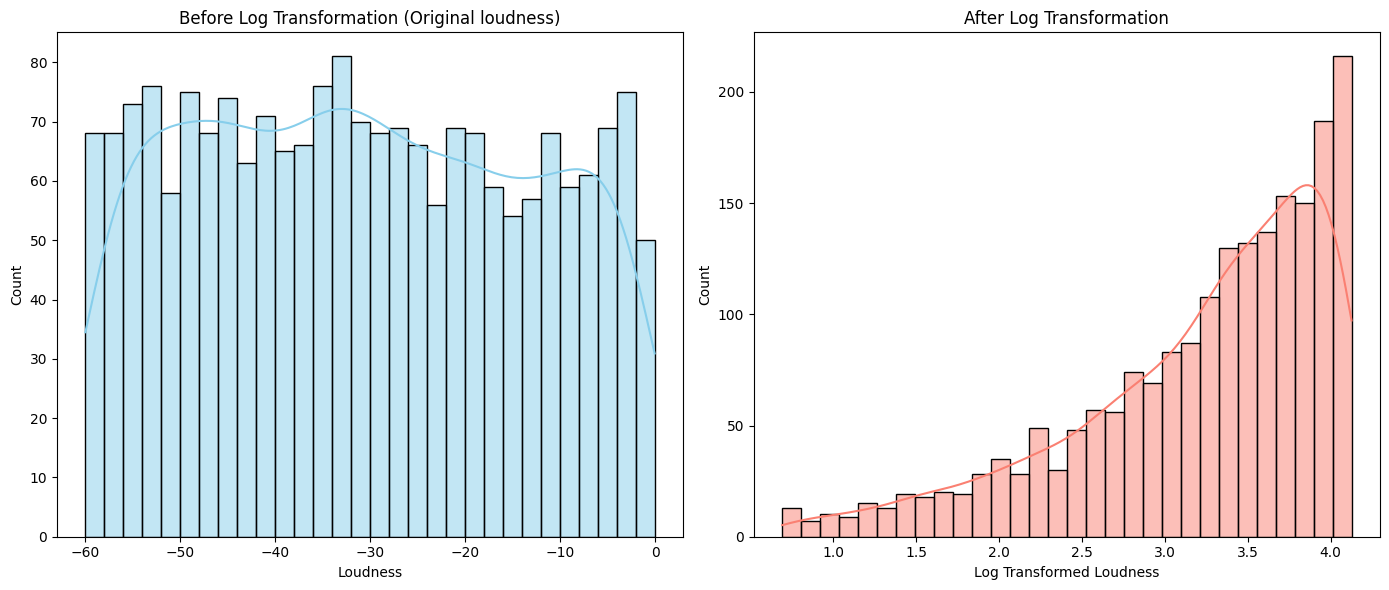

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from the CSV file
df = pd.read_csv(path+'/spotify_synthetic_data.csv')  # Replace with the actual path

# Apply log1p transformation to the 'loudness' column after shifting the values to positive
df['log_loudness'] = np.log1p(df['loudness'] - df['loudness'].min() + 1)

# Plot before and after log transformation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original Loudness
sns.histplot(df['loudness'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Before Log Transformation (Original loudness)')
axes[0].set_xlabel('Loudness')

# Log-Transformed Loudness
sns.histplot(df['log_loudness'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('After Log Transformation')
axes[1].set_xlabel('Log Transformed Loudness')

plt.tight_layout()
plt.show()


## Binning

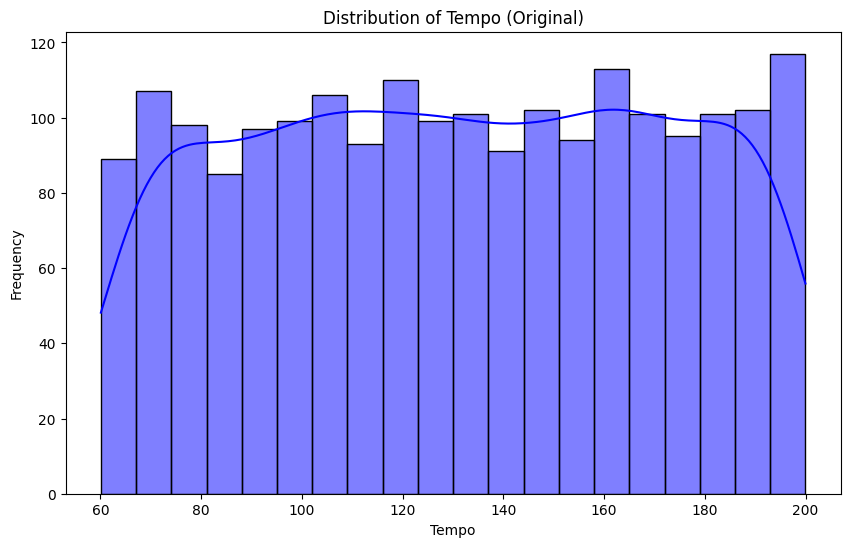

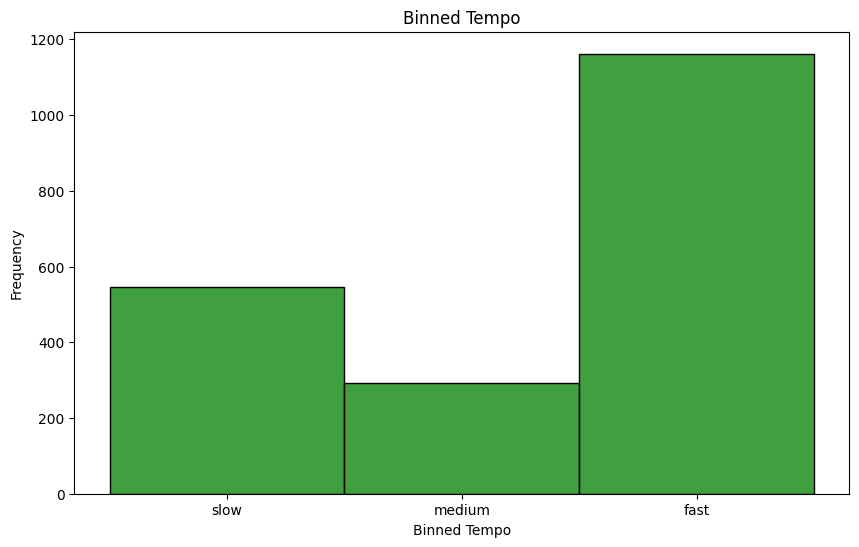

  track_name       tempo binned_tempo
0    Track_1  130.891275         fast
1    Track_2  128.628400         fast
2    Track_3  110.653032       medium
3    Track_4  199.184331         fast
4    Track_5   75.563707         slow


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from the CSV file
df = pd.read_csv(path+'/spotify_synthetic_data.csv')  # Replace with the actual path

# Plot the original 'tempo' distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['tempo'], bins=20, kde=True, color='blue')
plt.title("Distribution of Tempo (Original)")
plt.xlabel("Tempo")
plt.ylabel("Frequency")
plt.show()

# Apply binning to 'tempo'
# Define the bins (ranges of tempo)
bins = [0, 100, 120, 200]
labels = ['slow', 'medium', 'fast']

# Create a new column with binned 'tempo'
df['binned_tempo'] = pd.cut(df['tempo'], bins=bins, labels=labels, right=False)

# Visualize the data after binning
plt.figure(figsize=(10, 6))
sns.histplot(df['binned_tempo'], kde=False, color='green')
plt.title("Binned Tempo")
plt.xlabel("Binned Tempo")
plt.ylabel("Frequency")
plt.show()

# Display the first few rows of the dataset with binned values
print(df[['track_name', 'tempo', 'binned_tempo']].head())


## Model Training and Evaluation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

df = pd.read_csv(path+'/spotify_synthetic_data.csv')

# Step 1: Preprocessing the data
# We will predict the 'genre' column, and the rest of the columns will be features
X = df.drop(columns=['track_name', 'artist', 'album', 'genre'])  # Features (excluding non-numeric columns)
y = df['genre']  # Target variable (genre)

In [ ]:
# Step 2: Encode the categorical target variable 'genre' using LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [ ]:
# Step 3: Split the data into training and testing sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

In [ ]:
# Step 4: Create a pipeline with scaling and Logistic Regression classifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: Scaling the data
    ('classifier', LogisticRegression(max_iter=1000))  # Step 2: Fitting a Logistic Regression model
])



In [ ]:
# Step 5: Fit the pipeline (automatically applies scaling then fits the classifier)
pipeline.fit(X_train, y_train)

# Step 6: Make predictions on the test set
y_pred = pipeline.predict(X_test)

In [ ]:
# Step 7: Evaluate the model accuracy
score = pipeline.score(X_test, y_test)
print(f'Accuracy: {score}')

Accuracy: 0.125


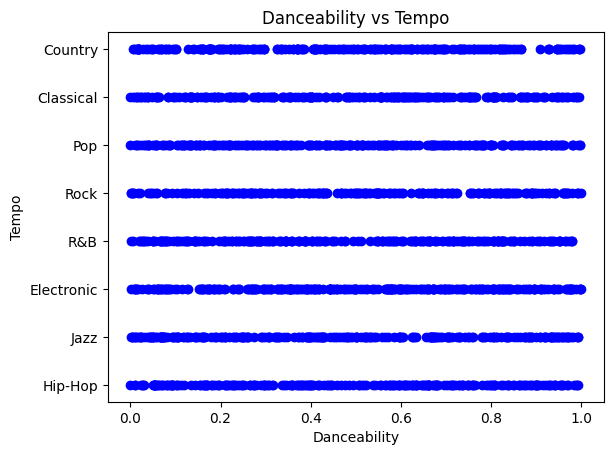

In [ ]:
# Visualize the original data (for one feature vs target)
# Visualize 'danceability' vs 'tempo' for simplicity
plt.scatter(X['danceability'], y, color='blue')
plt.title('Danceability vs Tempo')
plt.xlabel('Danceability')
plt.ylabel('Tempo')
plt.show()

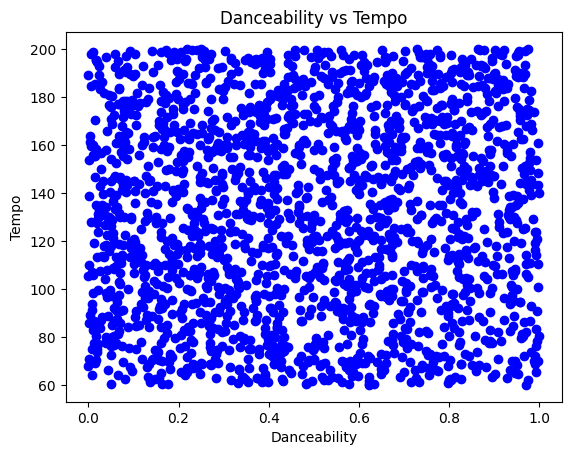

Mean Squared Error: 1806.934861628923


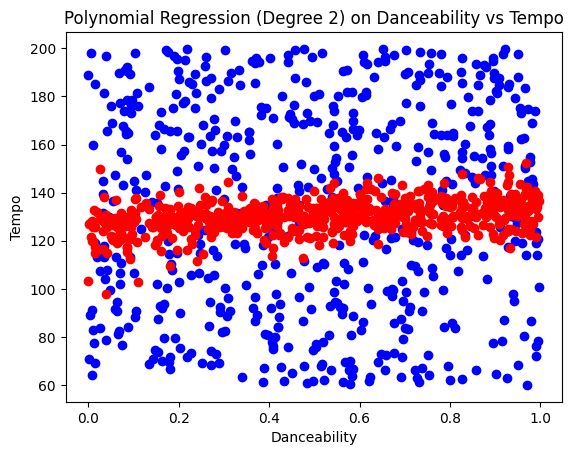

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error



# Step 1: Select the features (X) and target (y)
X = df[['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
        'instrumentalness', 'liveness', 'valence']]  # Features
y = df['tempo']  # Target variable (tempo)

# Step 2: Visualize the original data (for one feature vs target)
# Visualize 'danceability' vs 'tempo' for simplicity
plt.scatter(X['danceability'], y, color='blue')
plt.title('Danceability vs Tempo')
plt.xlabel('Danceability')
plt.ylabel('Tempo')
plt.show()

# Step 3: Generate Polynomial Features (degree 2)
poly = PolynomialFeatures(degree=2)  # Using degree 2 for quadratic features
X_poly = poly.fit_transform(X)  # Transforming the original features into polynomial features

# Step 4: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.3, random_state=42)

# Step 5: Train the Linear Regression Model using the Polynomial Features
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Step 6: Make Predictions
y_pred = lin_reg.predict(X_test)

# Step 7: Evaluate the Model (using Mean Squared Error)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Step 8: Visualize the Polynomial Regression Results (for one feature for simplicity)
# We will visualize 'danceability' vs predicted 'tempo'

plt.scatter(X_test[:, 1], y_test, color='blue')  # Plot the actual test data points (danceability vs actual tempo)
plt.scatter(X_test[:, 1], y_pred, color='red')  # Plot the predicted points
plt.title('Polynomial Regression (Degree 2) on Danceability vs Tempo')
plt.xlabel('Danceability')
plt.ylabel('Tempo')
plt.show()


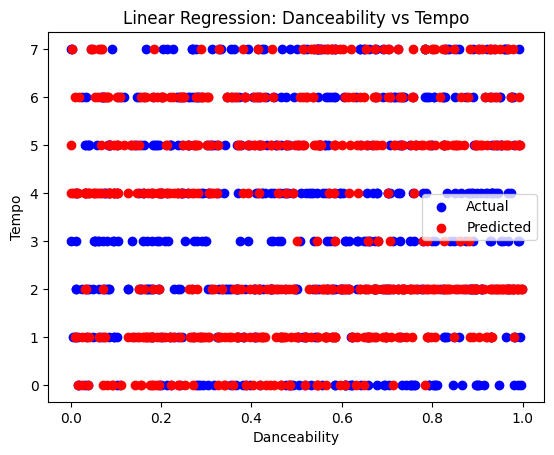

In [ ]:
# Step 9: Visualize the Linear Regression Results
# Since there are multiple features, we cannot visualize them directly in 2D.
# So, let's visualize how the model predicts 'tempo' based on 'danceability' as a simple example.

plt.scatter(X_test['danceability'], y_test, color='blue', label='Actual')  # Plot the actual test data points
plt.scatter(X_test['danceability'], y_pred, color='red', label='Predicted')  # Plot the predicted points
plt.title('Linear Regression: Danceability vs Tempo')
plt.xlabel('Danceability')
plt.ylabel('Tempo')
plt.legend()
plt.show()


# categorical data

## Label encoding:

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the dataset from the CSV file
df = pd.read_csv(path+'/spotify_synthetic_data.csv')  # Replace with the actual path

# Display the first few rows of the dataset to check
print("Original Data:")
print(df.head())

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Apply label encoding to the 'genre' column
df['genre_encoded'] = label_encoder.fit_transform(df['genre'])

# Display the first few rows of the dataset with the encoded genre
print("\nLabel Encoded Data:")
print(df[['track_name', 'genre', 'genre_encoded']].head())


Original Data:
  track_name     artist     album  danceability    energy   loudness  \
0    Track_1  Artist_52  Album_12      0.808235  0.153784 -24.860740   
1    Track_2  Artist_93  Album_46      0.947688  0.886171 -59.490265   
2    Track_3  Artist_15  Album_32      0.072316  0.458519 -14.339641   
3    Track_4  Artist_72  Album_15      0.955115  0.564591 -17.219142   
4    Track_5  Artist_61  Album_16      0.522577  0.663027 -38.022817   

   speechiness  acousticness  instrumentalness  liveness   valence  \
0     0.648209      0.575719          0.289405  0.760808  0.155540   
1     0.413194      0.583386          0.662430  0.850780  0.963687   
2     0.405619      0.749987          0.613122  0.257006  0.946790   
3     0.679552      0.509890          0.531003  0.407092  0.336110   
4     0.067094      0.104823          0.682964  0.498569  0.639748   

        tempo       genre  
0  130.891275     Hip-Hop  
1  128.628400        Jazz  
2  110.653032     Hip-Hop  
3  199.184331     H

## OneHotEncoder
Encoding Categorical Features

One-Hot Encoding: Converts categorical features into numerical features.

In [ ]:
import pandas as pd

# Load the dataset from the CSV file
#df = pd.read_csv(path+'/spotify_synthetic_data.csv')

# Display the first few rows of the dataset to check
print("Original Data:")
print(df.head())

# Perform One-Hot Encoding on the 'genre' column
df_encoded = pd.get_dummies(df, columns=['genre'], prefix='genre')

# Display the dataset after One-Hot Encoding
print("\nData after One-Hot Encoding:")
print(df_encoded.head())


Original Data:
  track_name     artist     album  danceability    energy   loudness  \
0    Track_1  Artist_52  Album_12      0.808235  0.153784 -24.860740   
1    Track_2  Artist_93  Album_46      0.947688  0.886171 -59.490265   
2    Track_3  Artist_15  Album_32      0.072316  0.458519 -14.339641   
3    Track_4  Artist_72  Album_15      0.955115  0.564591 -17.219142   
4    Track_5  Artist_61  Album_16      0.522577  0.663027 -38.022817   

   speechiness  acousticness  instrumentalness  liveness   valence  \
0     0.648209      0.575719          0.289405  0.760808  0.155540   
1     0.413194      0.583386          0.662430  0.850780  0.963687   
2     0.405619      0.749987          0.613122  0.257006  0.946790   
3     0.679552      0.509890          0.531003  0.407092  0.336110   
4     0.067094      0.104823          0.682964  0.498569  0.639748   

        tempo       genre  
0  130.891275     Hip-Hop  
1  128.628400        Jazz  
2  110.653032     Hip-Hop  
3  199.184331     H

## Target encoding:

In [ ]:
import pandas as pd


# Display the first few rows of the dataset to check
print("Original Data:")
print(df.head())

# Target Encoding: Replace each category in 'genre' with the mean of 'danceability' for that genre
mean_encoded = df.groupby('genre')['danceability'].mean()

# Map the mean values back to the 'genre' column
df['genre_encoded'] = df['genre'].map(mean_encoded)

# Display the dataset after Target Encoding
print("\nData with Target Encoding:")
print(df[['track_name', 'genre', 'danceability', 'genre_encoded']].head())


Original Data:
  track_name     artist     album  danceability    energy   loudness  \
0    Track_1  Artist_52  Album_12      0.808235  0.153784 -24.860740   
1    Track_2  Artist_93  Album_46      0.947688  0.886171 -59.490265   
2    Track_3  Artist_15  Album_32      0.072316  0.458519 -14.339641   
3    Track_4  Artist_72  Album_15      0.955115  0.564591 -17.219142   
4    Track_5  Artist_61  Album_16      0.522577  0.663027 -38.022817   

   speechiness  acousticness  instrumentalness  liveness   valence  \
0     0.648209      0.575719          0.289405  0.760808  0.155540   
1     0.413194      0.583386          0.662430  0.850780  0.963687   
2     0.405619      0.749987          0.613122  0.257006  0.946790   
3     0.679552      0.509890          0.531003  0.407092  0.336110   
4     0.067094      0.104823          0.682964  0.498569  0.639748   

        tempo       genre  
0  130.891275     Hip-Hop  
1  128.628400        Jazz  
2  110.653032     Hip-Hop  
3  199.184331     H